In [1]:
import torch
import pandas as pd
from tqdm import tqdm

from matplotlib import pyplot as plt
from matplotlib import ticker 

torch.manual_seed(42)

from dataclass import dataset

$$
\begin{array}{|c|l|c|c|}
\hline
 & \text{Reaction} & \text{Stoichiometry} & \text{Rate} \\
\hline
\text{Colonization} & \emptyset \to E & +1 & \alpha \\
\hline
\text{Replication} & E \to 2E & +1 & \mu E \\
\hline
\text{Competition} & E \to \emptyset & -1 & \left(\frac{\mu}{K}\right) E^2 \\
\hline
\text{Expulsion} & E \to \emptyset & -1 & dE \\
\hline
\end{array}
$$


In [2]:
# Loading the synthetic dataset
dseed = 0
df = pd.read_csv('synthetic_data/synth_seed{}.csv'.format(dseed))
df

,Time,Counts,Dilution
0,24.0,5,20.0
1,24.0,0,20.0
2,24.0,0,20.0
3,24.0,4,20.0
4,24.0,15,20.0
...,...,...,...
395,168.0,102,2000.0
396,168.0,129,2000.0
397,168.0,118,2000.0
398,168.0,94,2000.0


In [3]:
#Loading the ground truth

gt = pd.read_csv('synthetic_data/gt_map.csv', header=None, delim_whitespace=True).to_numpy()
gt = torch.tensor(gt[gt[:,0]==dseed][0,1:]).float()
gt

tensor([5.0000e-02, 2.5000e-01, 2.0000e+05, 1.0000e-03])

In [4]:
# The dataset need to be send to the `dataset` class
Ts     = df['Time'].to_numpy()
counts = df['Counts'].to_numpy()
dils   = df['Dilution'].to_numpy()
data = dataset(Ts,counts,dils)

Dataset loaded successfully.


In [5]:
#Define log posterior and check up in the lp_gt
value = torch.tensor( (1/20, 1/4, 2*1e5, 1e-3) ).to(data.device)
prior = torch.distributions.LogNormal(torch.log(value),torch.ones_like(value))
logposterior = lambda value,data: data.loglike(value) + prior.log_prob(value).sum()

lp_gt = logposterior(gt.to(data.device),data)
lp_gt

tensor(-1.1322, device='cuda:0', dtype=torch.float64)

In [6]:
def proposal(th,S_prop=1e-2):
    lth = torch.log(th)
    lprop = lth + torch.randn_like(th)*S_prop
    return torch.exp(lprop)

def next_MCMC_sample(params,lp,S_prop=1e2,burn=False):
    lp = logposterior(params,data) #While this is not usually necessary, the fact that we workon an approximation requires this recalculation to avoid the bias of a favorable semple of numbers.

    params_prop = proposal(params,S_prop)
    lp_prop = logposterior(params_prop,data)

    if burn:
        accept = (0 < (lp_prop-lp).item())
    else:
        accept = torch.log(torch.rand(1)).item() < (lp_prop-lp).item()
        
    if accept:
        lp = lp_prop
        params = params_prop
    
    return params,lp

In [7]:
N_burn = 300
N_mcmc = 1000

In [8]:
mcmc_params =[]
mcmc_lps = []

In [9]:
gt

tensor([5.0000e-02, 2.5000e-01, 2.0000e+05, 1.0000e-03])

In [10]:
params = prior.sample()

params = data.ode_initialization(params)
lp = logposterior(params,data)

Initializing using mass-action similarity


  5%|▌         | 10/200 [00:04<01:29,  2.13it/s]

gradient: 0.006964059546589851 0.043441106146247244


  8%|▊         | 16/200 [00:07<01:21,  2.27it/s]

 10%|█         | 20/200 [00:08<01:19,  2.27it/s]

...

gradient: 2.857111940102186e-05 0.028951085637953233


 80%|████████  | 160/200 [01:04<00:14,  2.74it/s]

gradient: 1.3231176126282662e-05 0.028951081998565345


 84%|████████▍ | 169/200 [01:07<00:12,  2.49it/s]

gradient: 4.3633835957734846e-06 0.028951082655115163


In [11]:
S_prop = torch.linspace(.1,1e-2,N_burn)

for s in tqdm(range(N_burn+N_mcmc)):
    if (s+1)%10 == 0:
        print(s+1, 'lp', lp.item())
        print(params.cpu().numpy())


    params, lp = next_MCMC_sample(params, lp,(S_prop[s] if s<N_burn else 1e-2),burn=s<N_burn)
    mcmc_params.append(params*1)
    mcmc_lps.append(lp.item())

  1%|          | 9/1300 [01:18<3:08:57,  8.78s/it]

10 lp -2.561938736270444
[9.7656973e-02 2.9518598e-01 2.4332075e+05 2.8477755e-04]


  1%|▏         | 19/1300 [02:35<2:22:51,  6.69s/it]

20 lp -1.2657758477848517
[7.7711143e-02 1.3508154e-01 3.2779597e+05 2.6659516e-04]


  2%|▏         | 29/1300 [03:25<1:41:09,  4.78s/it]

...

 54%|█████▍    | 699/1300 [45:56<1:14:55,  7.48s/it]

700 lp -4.233202075254943
[1.6258463e-01 1.1539643e-01 3.1859094e+05 6.5963904e-05]


 55%|█████▍    | 709/1300 [47:11<1:14:41,  7.58s/it]

710 lp -4.191706146041306
[1.66853651e-01 1.11436546e-01 3.06445531e+05 6.68688808e-05]


 55%|█████▍    | 710/1300 [47:18<1:14:42,  7.60s/it]

In [ ]:
posterior_samples = torch.stack(mcmc_params[-N_mcmc:]).cpu().numpy()

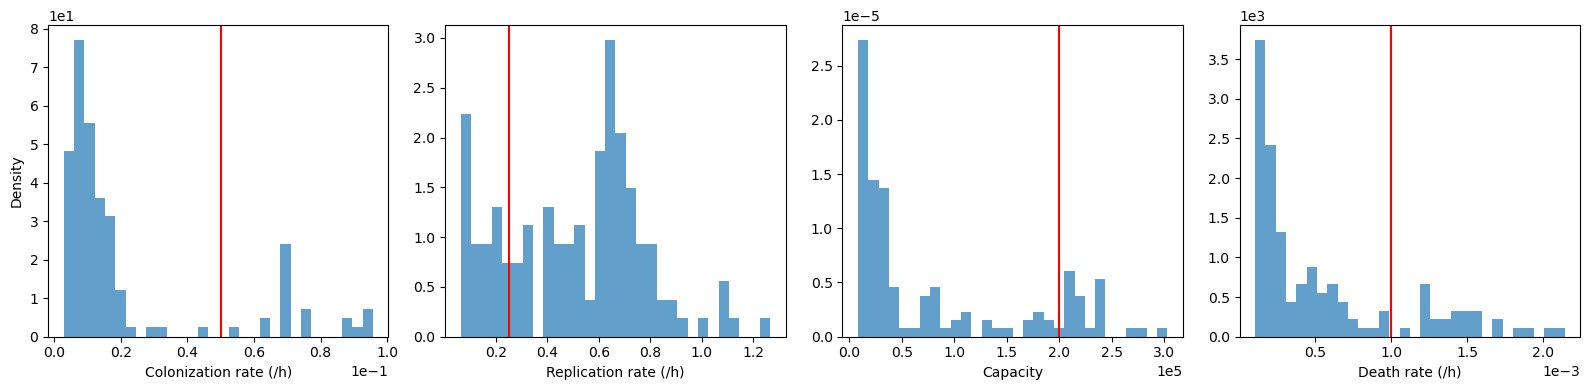

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
titles = ['Colonization rate (/h)','Replication rate (/h)','Capacity','Death rate (/h)']
for i in range(4):
    ax[i].hist(posterior_samples[:, i], bins=30, density=True, alpha=0.7)
    ax[i].set_xlabel(titles[i])
    ax[i].axvline(gt[i].item(),color='r')

formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
[axi.ticklabel_format(style='sci', axis='y', scilimits=(0, 0)) for axi in ax]
[axi.ticklabel_format(style='sci', axis='x', scilimits=(0, 0)) for axi in ax]

ax[0].set_ylabel('Density')
fig.tight_layout()
plt.show()

Text(0, 0.5, 'Log posterior')

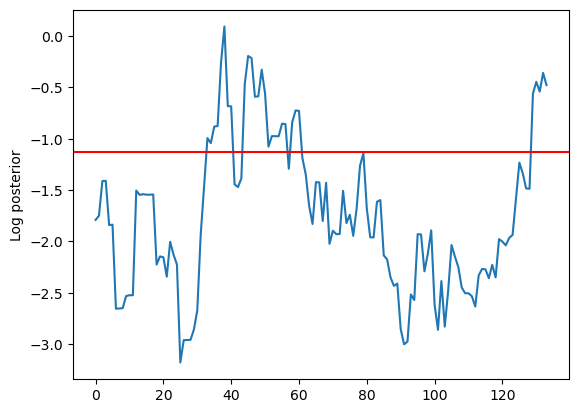

In [ ]:
plt.plot(mcmc_lps)
plt.axhline(lp_gt.item(),color='r')
plt.ylabel('Log posterior')